W eksperymencie z regresją liniową model był w stanie wyjaśnić ok. 60% zmienności cen mieszkań, co oznacza całkiem przyzwoite, ale nie idealne dopasowanie – wciąż sporo informacji o cenie „ucieka” poza prostą zależność liniową. Po przejściu na regresję wielomianową jakość prognoz zauważalnie się poprawia: model lepiej przewiduje zależności w danych, a błędy przewidywania są wyraźnie mniejsze, co w praktyce przekłada się na trafniejsze oszacowania cen. Różnica między modelami sugeruje, że zależność między cechami (np. dochodem, wiekiem zabudowy, liczbą pokoi) a ceną nie jest czysto liniowa i prosta prosta nie wystarcza, żeby dobrze opisać rynek nieruchomości. Jednocześnie poprawa nie jest „magiczna” – nawet model wielomianowy nadal nie wyjaśnia całej wariancji, co jest naturalne przy realnych danych obarczonych szumem i pominiętymi czynnikami, takimi jak lokalne preferencje czy stan techniczny konkretnych budynków.

Nazwy cech: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Średnie X: [ 3.87067100e+00  2.86394864e+01  5.42899974e+00  1.09667515e+00
  1.42547674e+03  3.07065516e+00  3.56318614e+01 -1.19569704e+02]
Odchylenia standardowe X: [1.89977569e+00 1.25852527e+01 2.47411320e+00 4.73899376e-01
 1.13243469e+03 1.03857980e+01 2.13590065e+00 2.00348319e+00]
Min X: [   0.4999        1.            0.84615385    0.33333333    3.
    0.69230769   32.54       -124.35      ]
Max X: [ 1.50001000e+01  5.20000000e+01  1.41909091e+02  3.40666667e+01
  3.56820000e+04  1.24333333e+03  4.19500000e+01 -1.14310000e+02]

Średnia y: 2.068558169089147
Odchylenie standardowe y: 1.1539282040412253
Min y: 0.14999
Max y: 5.00001


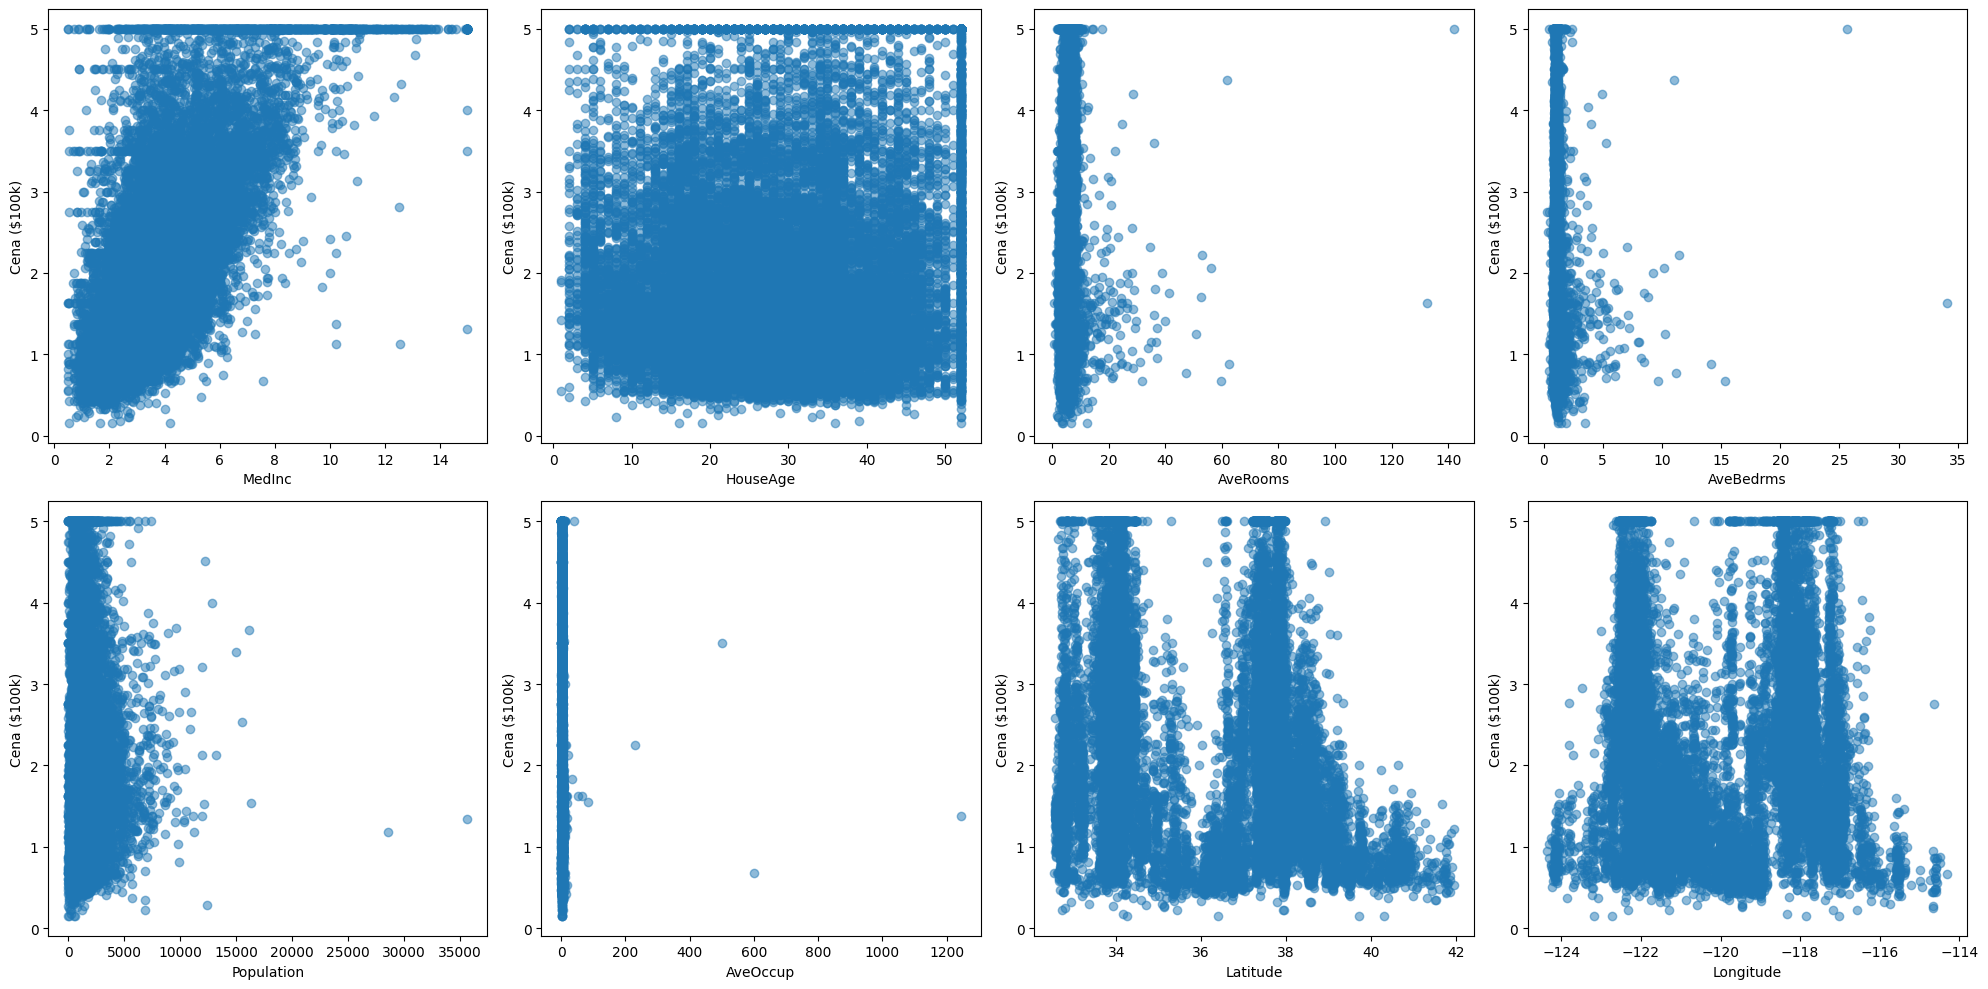

In [43]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings("ignore")

housing = fetch_california_housing()
X = housing.data
y = housing.target
names = housing.feature_names
print("Nazwy cech:", names)
#Podstawowe statystyki dla X
print("Średnie X:", X.mean(axis=0))
print("Odchylenia standardowe X:", X.std(axis=0))
print("Min X:", X.min(axis=0))
print("Max X:", X.max(axis=0))

#Podstawowe statystyki dla y
print("\nŚrednia y:", y.mean())
print("Odchylenie standardowe y:", y.std())
print("Min y:", y.min())
print("Max y:", y.max())
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(8):
    ax = axes[i//4, i%4]
    ax.scatter(X[:, i], y, alpha=0.5)
    ax.set_xlabel(names[i])
    ax.set_ylabel('Cena ($100k)')
plt.tight_layout()
plt.show()


Linear MSE: 0.5194536584827971
Linear R2 : 0.6027364496734411
Poly MSE: 0.4278685178484698
Poly R2 : 0.6727781897428395


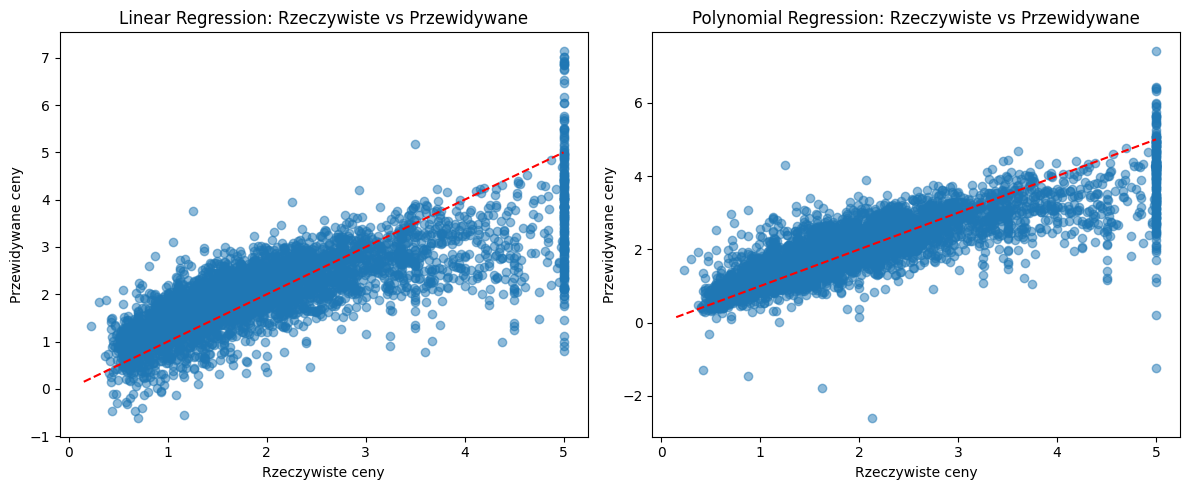

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

# model liniowy
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# model wielomianowy
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_poly_pred = poly_reg.predict(X_test_poly)

print("Linear MSE:", mean_squared_error(y_test, y_pred))
print("Linear R2 :", r2_score(y_test, y_pred))

print("Poly MSE:", mean_squared_error(y_test, y_poly_pred))
print("Poly R2 :", r2_score(y_test, y_poly_pred))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Rzeczywiste ceny')
plt.ylabel('Przewidywane ceny')
plt.title('Linear Regression: Rzeczywiste vs Przewidywane')


plt.subplot(1,2,2)
plt.scatter(y_test, y_poly_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Rzeczywiste ceny')
plt.ylabel('Przewidywane ceny')
plt.title('Polynomial Regression: Rzeczywiste vs Przewidywane')
plt.tight_layout()
plt.show()



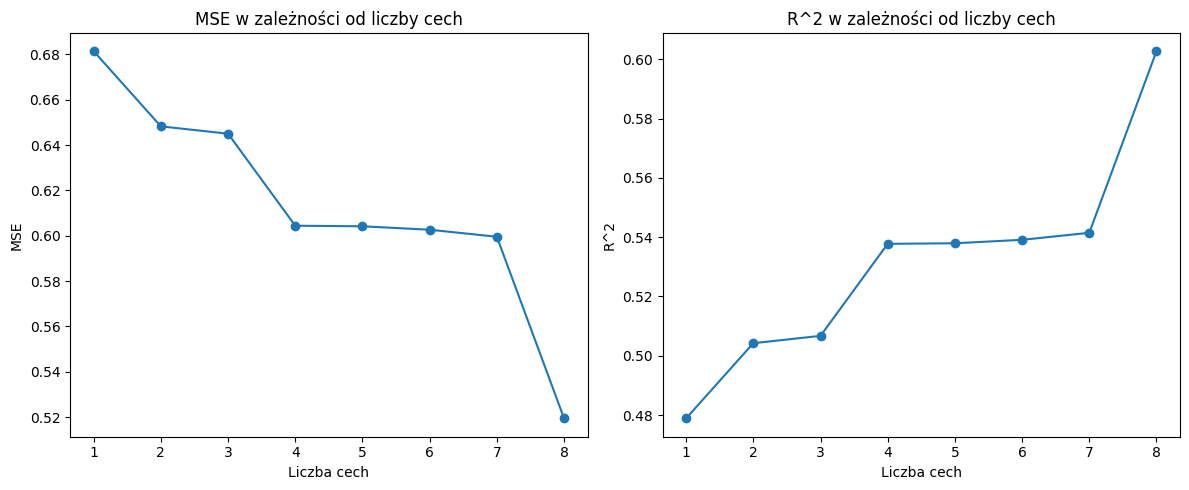

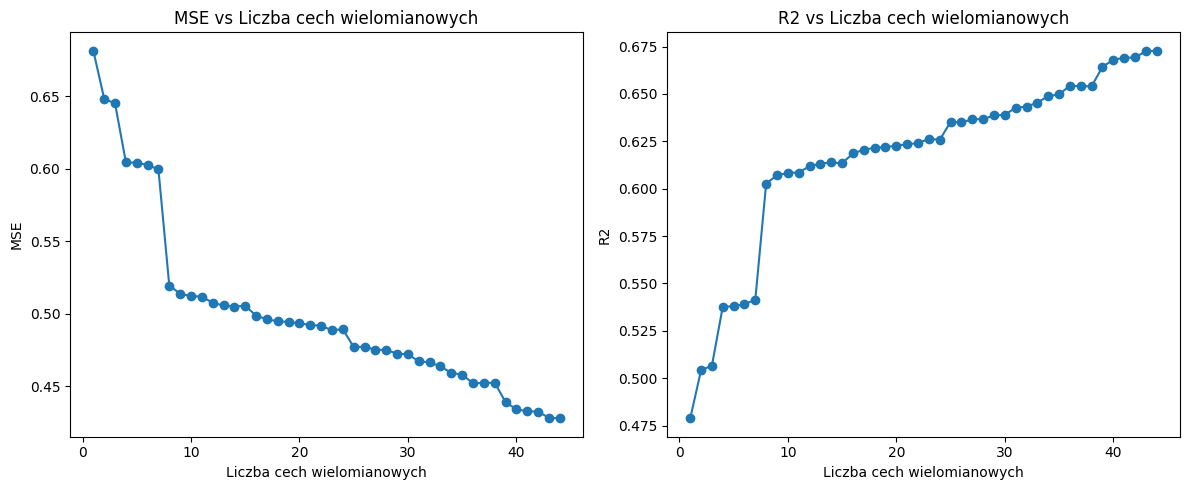

In [45]:
mse_list = []
r2_list = []

for i in range(1, X.shape[1] + 1):
    X_train_i = X_train[:, :i]
    X_test_i = X_test[:, :i]
    
    lr.fit(X_train_i, y_train)
    y_pred_i = lr.predict(X_test_i)
    
    mse_list.append(mean_squared_error(y_test, y_pred_i))
    r2_list.append(r2_score(y_test, y_pred_i))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, X.shape[1] + 1), mse_list, marker='o')
plt.xlabel('Liczba cech')
plt.ylabel('MSE')
plt.title('MSE w zależności od liczby cech')

plt.subplot(1, 2, 2)
plt.plot(range(1, X.shape[1] + 1), r2_list, marker='o')
plt.xlabel('Liczba cech')
plt.ylabel('R^2')
plt.title('R^2 w zależności od liczby cech')

plt.tight_layout()
plt.show()

####

n_features_poly = X_train_poly.shape[1]
mse_poly_list, r2_poly_list = [], []

for i in range(1, n_features_poly + 1):
    X_train_poly_i = X_train_poly[:, :i]
    X_test_poly_i = X_test_poly[:, :i]
    poly_reg.fit(X_train_poly_i, y_train)
    y_poly_pred_i = poly_reg.predict(X_test_poly_i)
    mse_poly_list.append(mean_squared_error(y_test, y_poly_pred_i))
    r2_poly_list.append(r2_score(y_test, y_poly_pred_i))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_features_poly + 1), mse_poly_list, marker='o')
plt.xlabel('Liczba cech wielomianowych')
plt.ylabel('MSE')
plt.title('MSE vs Liczba cech wielomianowych')
plt.subplot(1, 2, 2)
plt.plot(range(1, n_features_poly + 1), r2_poly_list, marker='o')
plt.xlabel('Liczba cech wielomianowych')
plt.ylabel('R2')
plt.title('R2 vs Liczba cech wielomianowych')
plt.tight_layout()
plt.show()

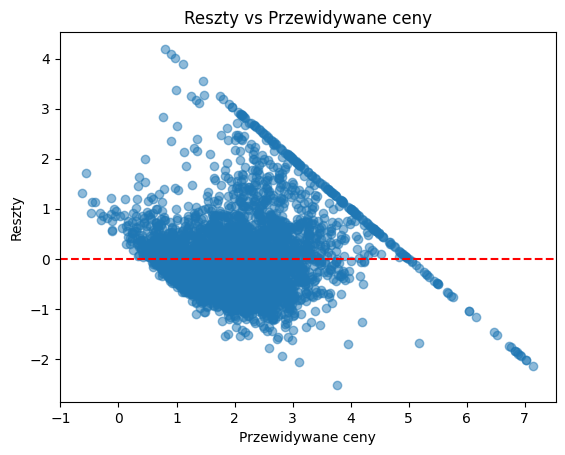

In [ ]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Przewidywane ceny')
plt.ylabel('Reszty')
plt.title('Reszty vs Przewidywane ceny')
plt.show()
